In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Task 1 - Data Loading and Auditing

### Task 1.1 
Load the data into a Pandas DataFrame, do an initial exploration of the dataset (e.g., checking its dimensions, attributes) and calculate some general statistics (e.g., using the `describe()` function). And communicate your findings.

In [7]:
df_rate: pd.DataFrame = pd.read_csv("Rate.csv")

In [6]:
n_rows: int; n_cols: int
n_rows, n_cols = df_rate.shape

In [9]:
# what are the variable types of columns in rate.csv?
df_rate.dtypes

BusinessYear                                   int64
StateCode                                     object
IssuerId                                       int64
SourceName                                    object
VersionNum                                     int64
ImportDate                                    object
IssuerId2                                      int64
FederalTIN                                    object
RateEffectiveDate                             object
RateExpirationDate                            object
PlanId                                        object
RatingAreaId                                  object
Tobacco                                       object
Age                                           object
IndividualRate                               float64
IndividualTobaccoRate                        float64
Couple                                       float64
PrimarySubscriberAndOneDependent             float64
PrimarySubscriberAndTwoDependents            f

### Task 1.2
Extract the following columns from the data, as we will only look into these columns in this exercise. 
We also include the descriptions of the columns here for your convenience.

- `BusinessYear`: Year for which plan provides coverage to enrollees.
- `StateCode`: Two-character state abbreviation indicating the state where the plan is offered.
- `IssuerId`: Five-digit numeric code that identifies the issuer organization in the Health Insurance Oversight System (HIOS).
- `PlanId`: Fourteen-character alpha-numeric code that identifies an insurance plan within HIOS. 
- `Age`: Categorical indicator of whether a subscriber's age is used to determine rate eligibility for the insurance plan.
- `IndividualRate`: Dollar value for the insurance premium cost applicable to a nontobacco user for the insurance plan in a rating area, or to a general subscriber if there is no tobacco preference.
- `IndividualTobaccoRate`: Dollar value for the insurance premium cost applicable to a tobacco user for the insurance plan in a rating area.

Assume we are only interested in the data in year 2014, therefore, let's extract the 2014 data.

In [12]:
# extract columns of interest
df_rate_slice: pd.DataFrame = df_rate[["BusinessYear", "StateCode", "IssuerId", "PlanId", "Age", "IndividualRate", "IndividualTobaccoRate"]]

In [45]:
# extract data from the year of interest
df_rate_slice_2014: pd.DataFrame = df_rate_slice[df_rate_slice["BusinessYear"] == 2014]
# check the shape of the extracted dataframe
df_rate_slice_2014.shape

(3796388, 7)

In [46]:
# check some statistics about the variables (columns in the dataframe)
df_rate_slice.describe()

,BusinessYear,IssuerId,IndividualRate,IndividualTobaccoRate
count,1.269444e+07,1.269444e+07,1.269444e+07,4.932349e+06
mean,2.015034e+03,5.248592e+04,4.098026e+03,5.436911e+02
std,7.940521e-01,2.641263e+04,6.122271e+04,2.945916e+02
min,2.014000e+03,1.004600e+04,0.000000e+00,4.173000e+01
25%,2.014000e+03,3.021900e+04,2.933000e+01,3.391200e+02
50%,2.015000e+03,4.953200e+04,2.916000e+02,4.632900e+02
75%,2.016000e+03,7.652600e+04,4.789800e+02,6.843900e+02
max,2.016000e+03,9.996900e+04,9.999990e+05,6.604610e+03


### Task 1.3 
Audit the data column `IndividualRate`. Do some statistics of the range of the values in the column `IndividualRate`. 
Show the distribution of `IndividualRate` values using boxplot and histogram. Communicate your findings: e.g., is there anything look suspicious to you? Are there any outliers? What do you think is a reasonable rate for individual
plans? [*Hint: you may have to adjust the limit of the y axis to be able to see the plot.*]

array([[<Axes: title={'center': 'IndividualRate'}>]], dtype=object)

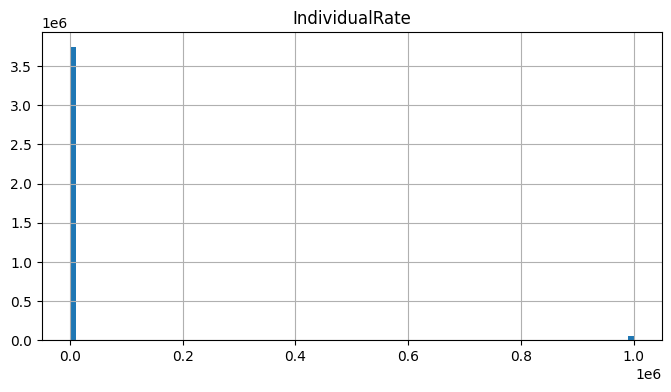

In [47]:
df_rate_slice_2014.hist(column="IndividualRate", bins=100, figsize=(8,4))

<Axes: title={'center': 'Boxplot of Individual Rate'}>

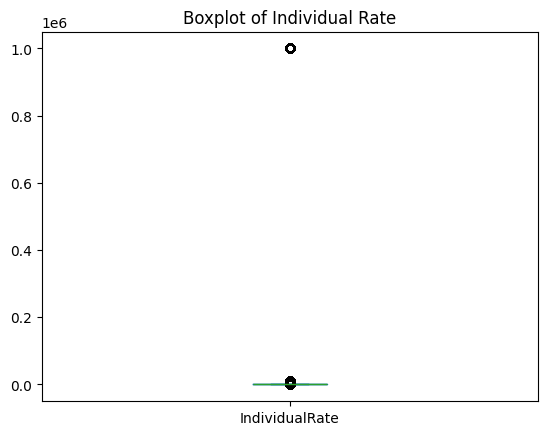

In [48]:
df_rate_slice_2014["IndividualRate"].plot(kind='box', title='Boxplot of Individual Rate')

The box plot is visualized too bad because the negaive impact of BoxPlot

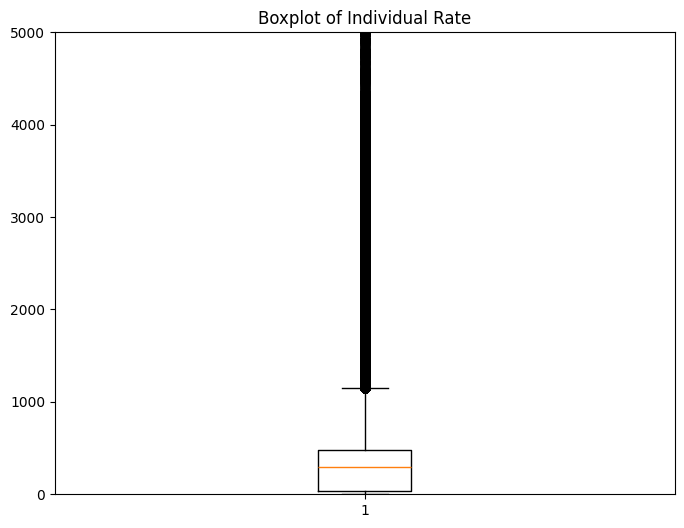

In [49]:
# Set limit the y-axis
fig, ax = plt.subplots(figsize=(8, 6))
data_to_plot = df_rate_slice_2014["IndividualRate"]

# 2. Create the boxplot
plt.boxplot(data_to_plot)

# 3. Add the title
plt.title('Boxplot of Individual Rate')
plt.ylim(0, 5000)
# 4. Show the plot
plt.show()

Use the IQR Range to remove the outlier

In [50]:
Q1: np.float64 = df_rate_slice_2014["IndividualRate"].quantile(0.25)
Q3: np.float64 = df_rate_slice_2014["IndividualRate"].quantile(0.75)
IQR: np.float64 = Q3 - Q1

lower_bound: np.float64 = Q1 - 1.5 * IQR
upper_bound: np.float64 = Q3 + 1.5 * IQR
df_rate_slice_2014_outlier: pd.DataFrame = df_rate_slice_2014[(df_rate_slice_2014['IndividualRate'] < lower_bound) | (df_rate_slice_2014['IndividualRate'] > upper_bound)]

In [51]:
df_interest_2014_normal = df_rate_slice_2014[(df_rate_slice_2014['IndividualRate'] >= lower_bound) & (df_rate_slice_2014['IndividualRate'] <= upper_bound)].reset_index(drop=True)

<Axes: >

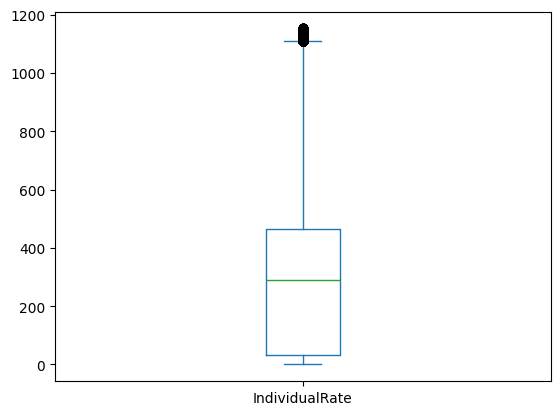

In [52]:
df_interest_2014_normal["IndividualRate"].plot(kind='box', title='')

## Task 2 - Carrier/Issuer and Plans Diversity Across Different States

In this subtask, you are required to investigate the number of carriers and available plan options in different states. To do this, you will have to calculate some statistics on the number of unique issuers as well as the number of unique plans in different states.

Visualize your results (e.g., using barchart) and communicate your findings, e.g., 
* Which state has the largest/least number of health insurance issuers or plans? 
* Use Google search (or any other information resource you preferred) to investigate whether this is related the population size of the state, e.g. Whether there are more plans for where there are larger populations?

### Task 2.1 
Which state has the largest/least number of health insurance issuers or plans?


In [53]:
# work on Task 2.1
df_rate_slice_2014.head()

,BusinessYear,StateCode,IssuerId,PlanId,Age,IndividualRate,IndividualTobaccoRate
0,2014,AK,21989,21989AK0010001,0-20,29.00,NaN
1,2014,AK,21989,21989AK0020001,Family Option,36.95,NaN
2,2014,AK,21989,21989AK0020001,Family Option,36.95,NaN
3,2014,AK,21989,21989AK0010001,21,32.00,NaN
4,2014,AK,21989,21989AK0010001,22,32.00,NaN


In [54]:
df_rate_slice_nunique: pd.DataFrame = df_interest.groupby(by="StateCode").aggregate({"PlanId": "nunique", "IssuerId": "nunique"}).reset_index(drop=False).rename(
    columns={"PlanId": "count_plan", "IssuerId": "count_issue"}
)

In [56]:
df_rate_slice_nunique.head()

,StateCode,count_plan,count_issue
0,AK,203,13
1,AL,180,19
2,AR,249,16
3,AZ,730,38
4,DE,139,15


In [61]:
state_min_plan: np.ndarray = df_rate_slice_nunique[df_rate_slice_nunique["count_plan"] == df_rate_slice_nunique["count_plan"].min()]["StateCode"].values
state_max_plan: np.ndarray = df_rate_slice_nunique[df_rate_slice_nunique["count_plan"] == df_rate_slice_nunique["count_plan"].max()]["StateCode"].values

In [63]:
print(f"state_min_plan: {state_min_plan}")
print(f"state_max_plan: {state_max_plan}")

state_min_plan: ['HI']
state_max_plan: ['WI']


In [62]:
state_min_issue: np.ndarray = df_rate_slice_nunique[df_rate_slice_nunique["count_issue"] == df_rate_slice_nunique["count_issue"].min()]["StateCode"].values
state_max_issue: np.ndarray = df_rate_slice_nunique[df_rate_slice_nunique["count_issue"] == df_rate_slice_nunique["count_issue"].max()]["StateCode"].values

In [64]:
print(f"state_min_issue: {state_min_issue}")
print(f"state_max_issue: {state_max_issue}")

state_min_issue: ['HI']
state_max_issue: ['TX']


### Task 2.2
Whether there are more plans for states with larger populations? [*Hint: you might find the data in 'nst-est2016-01.xlsx', which contains the population by state for the year of 2016, to be useful. Note we provided a reformatted version, the original version can be found [here](https://www2.census.gov/programs-surveys/popest/tables/2010-2016/state/totals/).*]

In [66]:
df_nst: pd.DataFrame = pd.read_excel("nst-est2016-01.xls")

In [70]:
# work on Task 2.2
sate_max_polution: np.ndarray = df_nst[df_nst[2014] == df_nst[2014].max()]["State"].values
sate_min_polution: np.ndarray = df_nst[df_nst[2014] == df_nst[2014].min()]["State"].values

In [71]:
print(f"sate_max_polution: {sate_max_polution}")
print(f"sate_min_polution: {sate_min_polution}")

sate_max_polution: ['CA']
sate_min_polution: ['WY']


## Task 3:  Carrier/Issuer and Plans Availability of Non-smoker vs. Smoker Across Different States

* How many issuers offer plans to non-smokers vs. smokers across different states? And,
* How about the number of available plans for non-smokers vs. smokers across different states?
* Do all states provided plans for tobacco users?

Note that non-smokers are paying on the `IndividualRate`, while smokers/tobacco users will need to pay the `IndividualTobaccoRate`. [*Hint: Therefore, a plan is available to a non-smoker only if the `IndividualRate` has an entry (not NaN, nor invalide entry). Similarly, a plan is available to a smoker only if the `IndividualTobaccoRate` is valid. So you will have to see how
many plans contain valid values in each case.*]

In [104]:
df_rate[["IndividualRate", "IndividualTobaccoRate"]].head()

,IndividualRate,IndividualTobaccoRate
0,29.00,NaN
1,36.95,NaN
2,36.95,NaN
3,32.00,NaN
4,32.00,NaN


In [105]:
df_rate_slice_2014_smoke: pd.DataFrame = df_rate_slice_2014.copy()

In [106]:
df_rate_slice_2014_smoke["is_smoke"] = ~df_rate_slice_2014_smoke["IndividualTobaccoRate"].isna()

### Task 3.1
How many issuers offer plans to non-smokers vs. smokers across different states?

In [111]:
smoke: pd.DataFrame = df_rate_slice_2014_smoke[df_rate_slice_2014_smoke["is_smoke"]].groupby(by="StateCode").aggregate({"IssuerId": "nunique"}).reset_index(drop=False).rename(
    columns={"IssuerId": "num_issue_smoke"}
)

not_smoke: pd.DataFrame = df_rate_slice_2014_smoke[~df_rate_slice_2014_smoke["is_smoke"]].groupby(by="StateCode").aggregate({"IssuerId": "nunique"}).reset_index(drop=False).rename(
    columns={"IssuerId": "num_issue_not_smoke"}
)

In [112]:
len(not_smoke), len(smoke)

(36, 35)

In [113]:
smoke_stats: pd.DataFrame = pd.merge(not_smoke, smoke, how="outer")

In [114]:
smoke_stats.head()

,StateCode,num_issue_not_smoke,num_issue_smoke
0,AK,8,1.0
1,AL,9,2.0
2,AR,8,2.0
3,AZ,15,8.0
4,DE,6,3.0


### Task 3.2
How many available plans for non-smokers vs. smokers across different states?

In [123]:
smoke: pd.DataFrame = df_rate_slice_2014_smoke[df_rate_slice_2014_smoke["is_smoke"]].groupby(by="StateCode").aggregate({"PlanId": "nunique"}).reset_index(drop=False).rename(
    columns={"PlanId": "num_plan_smoke"}
)

not_smoke: pd.DataFrame = df_rate_slice_2014_smoke[~df_rate_slice_2014_smoke["is_smoke"]].groupby(by="StateCode").aggregate({"PlanId": "nunique"}).reset_index(drop=False).rename(
    columns={"PlanId": "num_plan_not_smoke"}
)

In [124]:
len(not_smoke), len(smoke)

(36, 35)

In [125]:
smoke_stats: pd.DataFrame = pd.merge(not_smoke, smoke, how="outer")

In [126]:
smoke_stats.head()

,StateCode,num_plan_not_smoke,num_plan_smoke
0,AK,68,24.0
1,AL,75,17.0
2,AR,87,60.0
3,AZ,225,172.0
4,DE,36,32.0


### Task 3.3
Do all states provided plans for tobacco users?

In [140]:
states: np.ndarray = df_rate_slice_2014_smoke["StateCode"].unique()
n_state: int = len(states)

In [141]:
tobacoo_sates: np.ndarray = df_rate_slice_2014_smoke[~df_rate_slice_2014_smoke["IndividualTobaccoRate"].isna()]["StateCode"].unique()
n_tobacoo_sate: int = len(tobacoo_sates)

In [142]:
print("All sates provided plans for tobacco") if n_state == n_state_tobacco else print("All sates did not provide plans for tobacco")

All sates did not provide plans for tobacco


In [144]:
miss_states: int = set(states) - set(tobacoo_sates)
miss_states

{'NJ'}

## Task 4: Rates for non-smoker vs. smoker across different states
Now, let move our focus to the cost/rates of insurance plans. Let us compare the average insurance rates of non-smokers vs. smokers in different states.

Visualize your results and communicate your findings, e.g., do non-smokers and smokers pay the same rate? If not, in general, what are the differences? Who are paying
higher rates？

In [187]:
df_smoke: pd.DataFrame = df_rate_slice_2014_smoke[df_rate_slice_2014_smoke["is_smoke"]]

In [188]:
smoke_stats: pd.DataFrame = df_smoke.groupby(by="StateCode").aggregate({"IndividualRate": "mean"}).reset_index(drop=False).rename(
    columns={"IndividualRate": "avg_cost_smoke"}
)


In [189]:
df_not_smoke: pd.DataFrame = df_rate_slice_2014_smoke[~df_rate_slice_2014_smoke["is_smoke"]]

In [191]:
not_smoke_stats: pd.DataFrame = df_not_smoke.groupby(by="StateCode").aggregate({"IndividualRate": "mean"}).reset_index(drop=False).rename(
    columns={"IndividualRate": "avg_cost_not_smoke"}
)


In [193]:
all_stats: pd.DataFrame = pd.merge(not_smoke_stats, smoke_stats, how="outer")

In [195]:
all_stats.head()

,StateCode,avg_cost_not_smoke,avg_cost_smoke
0,AK,31627.835255,565.330012
1,AL,32285.316543,345.458431
2,AR,46557.946239,437.333906
3,AZ,11058.169389,456.104482
4,DE,30.908869,451.703020


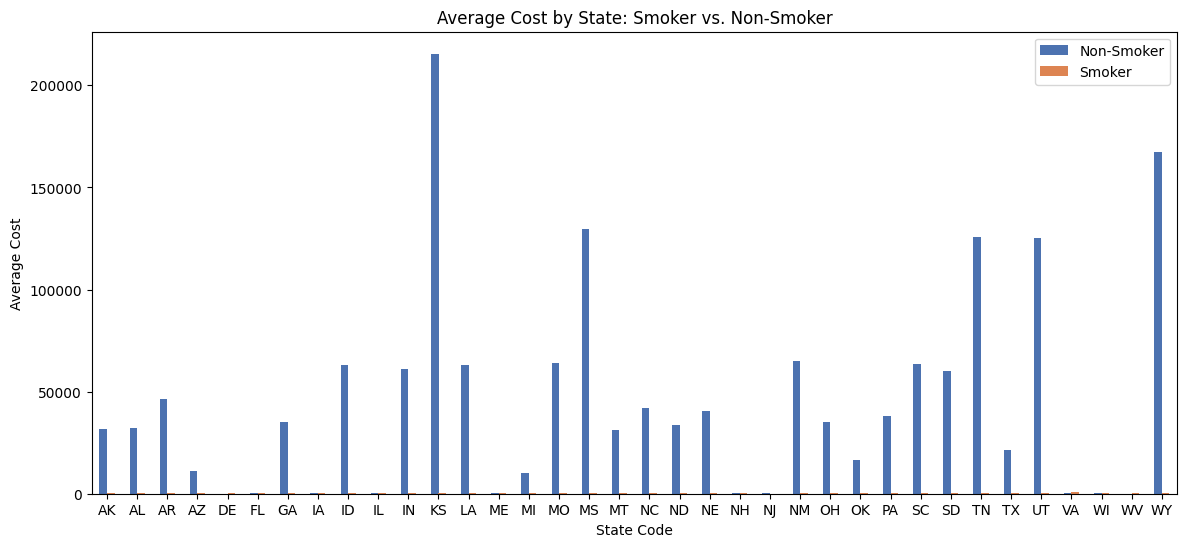

In [196]:
# 1. Set StateCode as the index (so they appear on the x-axis)
df_plot = all_stats.set_index('StateCode')

# 2. Plot the columns as a grouped bar chart
# Notice we removed stacked=True. This is all it takes!
df_plot[['avg_cost_not_smoke', 'avg_cost_smoke']].plot(
    kind='bar', 
    figsize=(14, 6),             # Made it slightly wider to fit the side-by-side bars
    color=['#4C72B0', '#DD8452'] # Custom colors
)

# 3. Customize the chart
plt.title('Average Cost by State: Smoker vs. Non-Smoker')
plt.xlabel('State Code')
plt.ylabel('Average Cost')

# Optional: Rotate the x-axis labels so they are easier to read
plt.xticks(rotation=0) 

# Clean up the legend
plt.legend(['Non-Smoker', 'Smoker'])

# 4. Show the plot
plt.show()